# Hybrid Stacking XAU/USD — Visualization Pipeline


## 1. Imports & Style


In [1]:
import warnings
import time
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import polars as pl

from accelerate import Accelerator
from accelerate.utils import set_seed
from src.backtest import simulate_equity_barrier, aggregate_backtest_metrics
from src.config import (
    ADX_THRESHOLD, AUTO_TUNE_BARRIERS, BB_WIDTH_MIN_MULT,
    CONFIDENCE_THRESHOLD, CV_SPLITS, DATA_DIR, EMBARGO_PCT,
    FALLBACK_SL_ATR, FALLBACK_TP_ATR, FRACTIONAL_D, INITIAL_BALANCE,
    LABELING_HORIZON, LABELS, MAX_LOSS_ATR, META_LABEL_THRESHOLD,
    MIN_OOF_F1, PURGE_PCT, RANDOM_STATE, REPORT_DIR,
    SHORT_META_LABEL_THRESHOLD, SWING_WINDOW, TEST_SIZE, 
    TUNE_SL_RANGE, TUNE_TP_RANGE, TUNE_TARGET_BALANCE,
    USE_META_LABELING, PipelineConfig,
)
from src.data import collect_parquet_file_paths
from src.dataset import (
    apply_labels_to_frame, auto_calibrate_barrier_widths,
    derive_train_test_split, extract_feature_columns, load_featured_candles,
)
from src.features import derive_fractionally_differentiated_series
from src.models import HybridStackingSignalClassifier
from src.validation import PurgedEmbargoTimeSeriesSplit

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10})

PALETTE = {1: "#2ca02c", 0: "#7f7f7f", -1: "#d62728"}
LABEL_NAMES = {-1: "SHORT", 0: "HOLD", 1: "LONG"}
LABEL_ORDER = list(LABELS)

set_seed(RANDOM_STATE)
accelerator = Accelerator()
print(f"Accelerate device: {accelerator.device} | processes: {accelerator.num_processes}")

_t0 = time.perf_counter()
_timings: dict[str, float] = {}
_figures: list[plt.Figure] = []


Accelerate device: cpu | processes: 1


## 2. Config & Data Discovery


In [2]:
config = PipelineConfig(months=None)

files = collect_parquet_file_paths(DATA_DIR, config.months)
months_label = "full" if config.months is None else f"{config.months} months"
file_range = f"{files[0].stem} - {files[-1].stem}"
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Mode: {months_label} | Parquet files: {len(files)}")
print(f"File range: {file_range}")

_timings["config"] = time.perf_counter() - _t0


Data dir: /home/ultimatebrok/Downloads/thesis-compact/data/XAUUSD
Mode: full | Parquet files: 60
File range: 2019-01 - 2023-12


## 3. Dataset Construction


In [3]:
_t_section = time.perf_counter()
featured = load_featured_candles(config)

tp_atr = FALLBACK_TP_ATR
sl_atr = FALLBACK_SL_ATR
if AUTO_TUNE_BARRIERS:
    split_idx = int(len(featured) * (1 - TEST_SIZE))
    train_portion = featured.head(split_idx)
    tp_atr, sl_atr, _, _ = auto_calibrate_barrier_widths(train_portion)

dataset = apply_labels_to_frame(featured, tp_atr=tp_atr, sl_atr=sl_atr)
train, test, _ = derive_train_test_split(dataset, test_size=TEST_SIZE, purge_pct=PURGE_PCT)
features = extract_feature_columns(dataset)

dataset_pdf = dataset.to_pandas().set_index("timestamp")
train_pdf = train.to_pandas().set_index("timestamp")
test_pdf = test.to_pandas().set_index("timestamp")

print(f"Rows (train+test): {len(dataset):,}")
print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Features: {len(features)}")
print(f"Raw close in features: {'close' in features}")
print(f"Fractional d: {FRACTIONAL_D}")
_timings["data_loading"] = time.perf_counter() - _t_section


Auto-tuned barriers: TP_ATR=1.5, SL_ATR=0.75, balance=0.355410538618876
Label distribution: {'SL (-1)': np.int64(9700), 'Time (0)': np.int64(3649), 'TP (+1)': np.int64(10267), 'total': 23616, 'balance_ratio': 0.3554}
Split at row 23396 | timestamp: 2023-01-03 16:00:00+00:00 | purge gap: 585 rows
Train: 2019-01-18 04:00:00+00:00 -> 2023-01-03 15:00:00+00:00
Test:  2023-02-08 07:00:00+00:00 -> 2023-12-28 20:00:00+00:00
Rows (train+test): 29,245
Train: 23,396 | Test: 5,264
Features: 21
Raw close in features: False
Fractional d: 0.4


## 4. Label Distribution


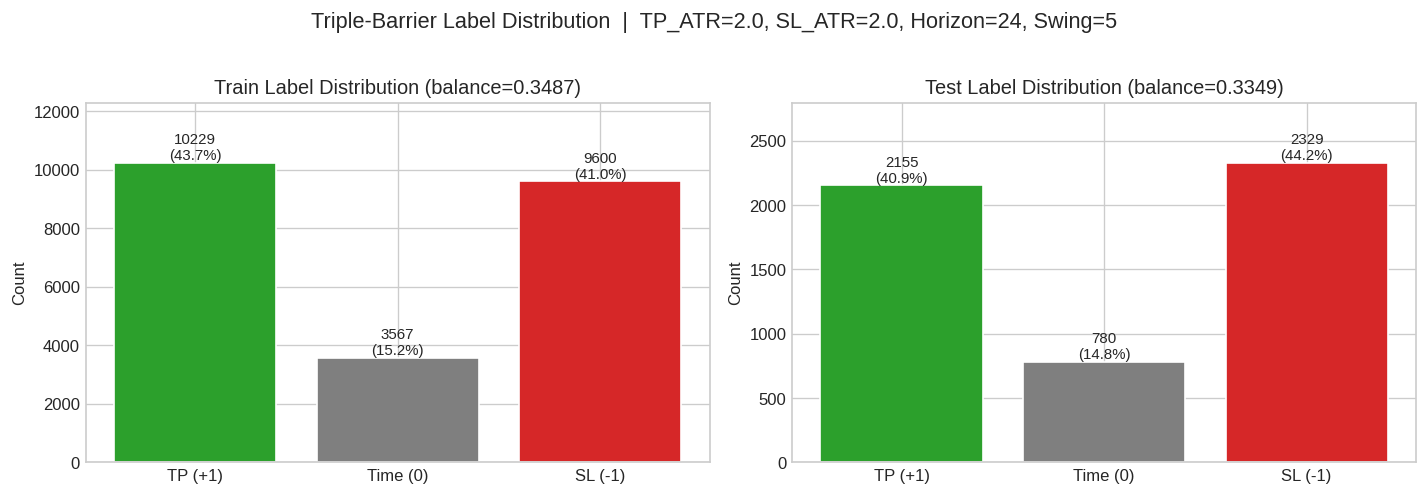

In [4]:
from src.labeling import summarize_label_distribution

train_labels = train["label"].to_numpy()
test_labels = test["label"].to_numpy()
train_dist = summarize_label_distribution(train_labels)
test_dist = summarize_label_distribution(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_figures.append(fig)

for ax, dist, title in zip(axes, [train_dist, test_dist], ["Train", "Test"]):
    categories = ["TP (+1)", "Time (0)", "SL (-1)"]
    values = [dist.get(c, 0) for c in categories]
    colors = ["#2ca02c", "#7f7f7f", "#d62728"]
    bars = ax.bar(categories, values, color=colors, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val}\n({val/dist['total']*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{title} Label Distribution (balance={dist['balance_ratio']:.4f})")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(values) * 1.2)

fig.suptitle(f"Triple-Barrier Label Distribution  |  TP_ATR={FALLBACK_TP_ATR}, SL_ATR={FALLBACK_SL_ATR}, Horizon={LABELING_HORIZON}, Swing={SWING_WINDOW}", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 5a. Fractional Differencing


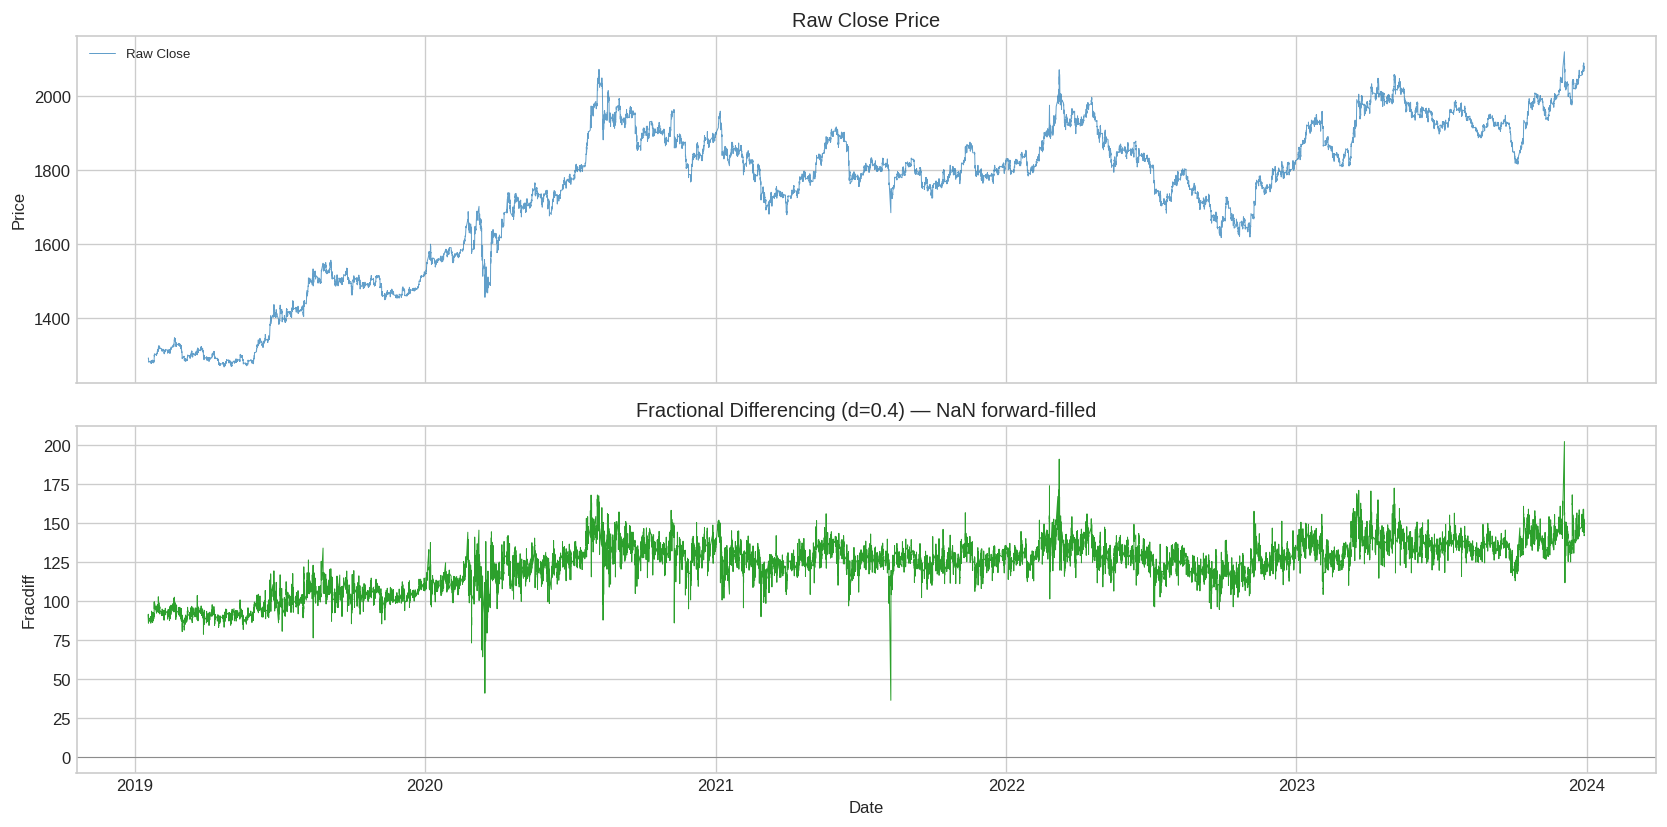

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
_figures.append(fig)

axes[0].plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", linewidth=0.6, alpha=0.7, label="Raw Close")
axes[0].set_title("Raw Close Price")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

axes[1].plot(dataset_pdf.index, dataset_pdf["close_fracdiff"], color="#2ca02c", linewidth=0.6)
axes[1].set_title(f"Fractional Differencing (d={FRACTIONAL_D}) — NaN forward-filled")
axes[1].set_ylabel("Fracdiff")
axes[1].set_xlabel("Date")
axes[1].axhline(0, color="gray", linewidth=0.5)

fig.tight_layout()


## 5b. Technical Indicators


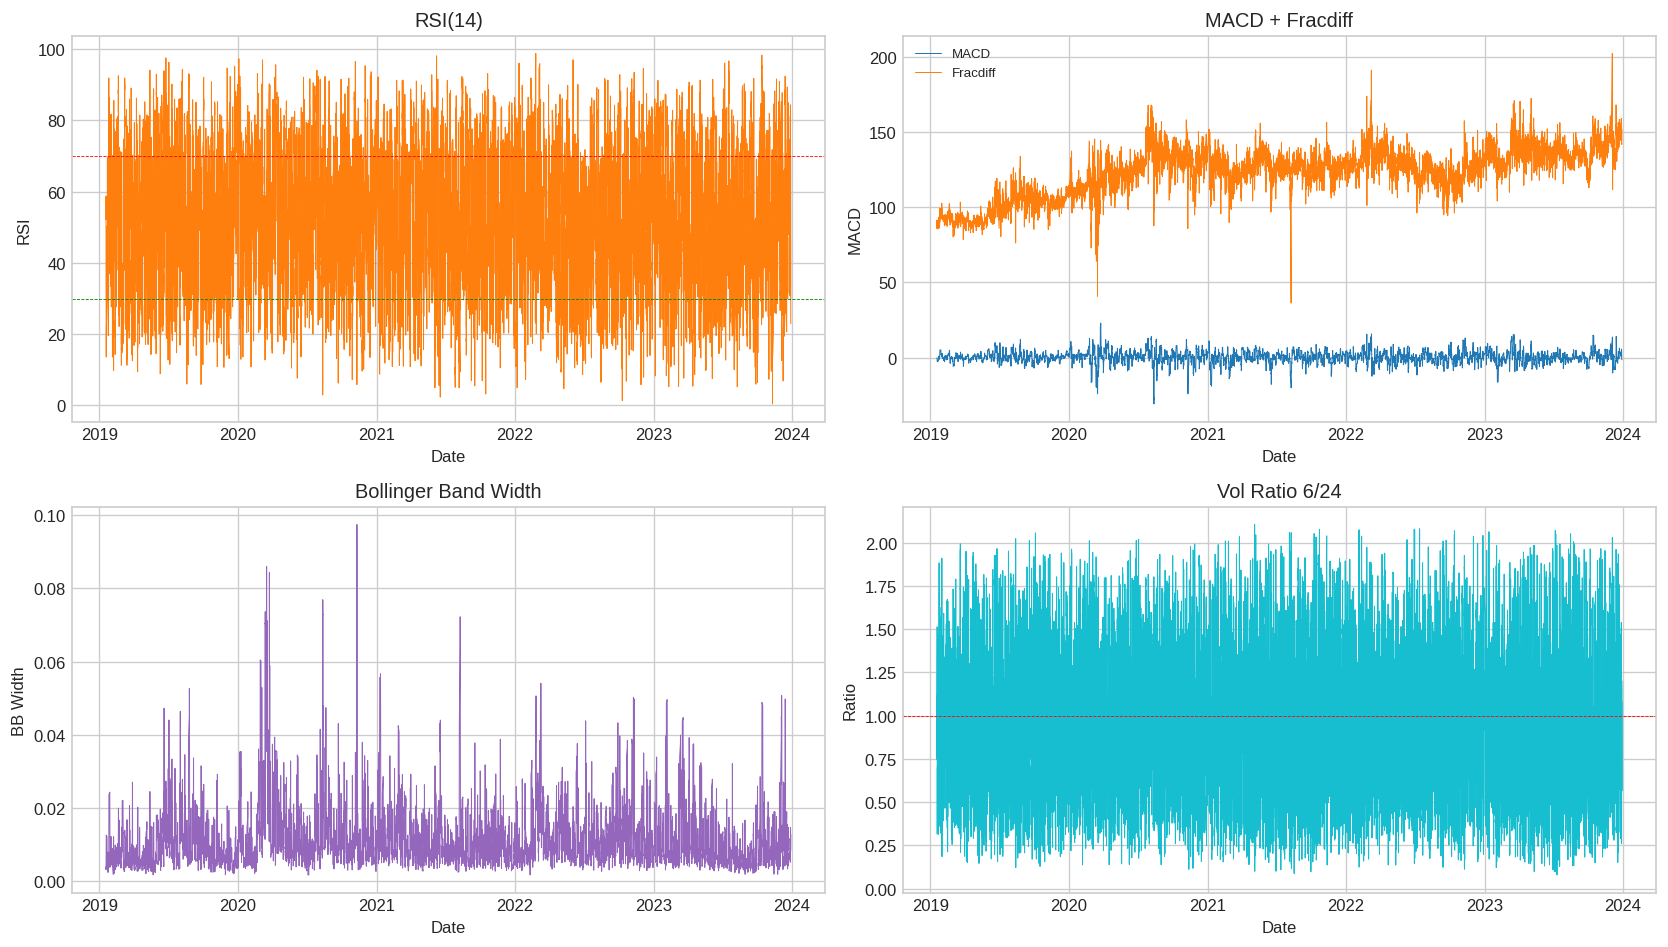

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
_figures.append(fig)

axes[0, 0].plot(dataset_pdf.index, dataset_pdf["rsi_14"], color="#ff7f0e", linewidth=0.6)
axes[0, 0].axhline(70, color="red", linewidth=0.5, linestyle="--")
axes[0, 0].axhline(30, color="green", linewidth=0.5, linestyle="--")
axes[0, 0].fill_between(dataset_pdf.index, 30, 70, alpha=0.1, color="gray")
axes[0, 0].set_title("RSI(14)")
axes[0, 0].set_ylabel("RSI")

axes[0, 1].plot(dataset_pdf.index, dataset_pdf["macd"], color="#1f77b4", linewidth=0.6, label="MACD")
axes[0, 1].plot(dataset_pdf.index, dataset_pdf["close_fracdiff"], color="#ff7f0e", linewidth=0.6, label="Fracdiff")
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title("MACD + Fracdiff")
axes[0, 1].set_ylabel("MACD")

axes[1, 0].plot(dataset_pdf.index, dataset_pdf["bb_width"], color="#9467bd", linewidth=0.6)
axes[1, 0].set_title("Bollinger Band Width")
axes[1, 0].set_ylabel("BB Width")

axes[1, 1].plot(dataset_pdf.index, dataset_pdf["vol_ratio_6_24"], color="#17becf", linewidth=0.6)
axes[1, 1].axhline(1.0, color="red", linewidth=0.5, linestyle="--")
axes[1, 1].set_title("Vol Ratio 6/24")
axes[1, 1].set_ylabel("Ratio")

for ax in axes.flat:
    ax.set_xlabel("Date")
fig.tight_layout()


## 5c. Feature Correlation


Text(0.5, 1.0, 'Feature Correlation Matrix')

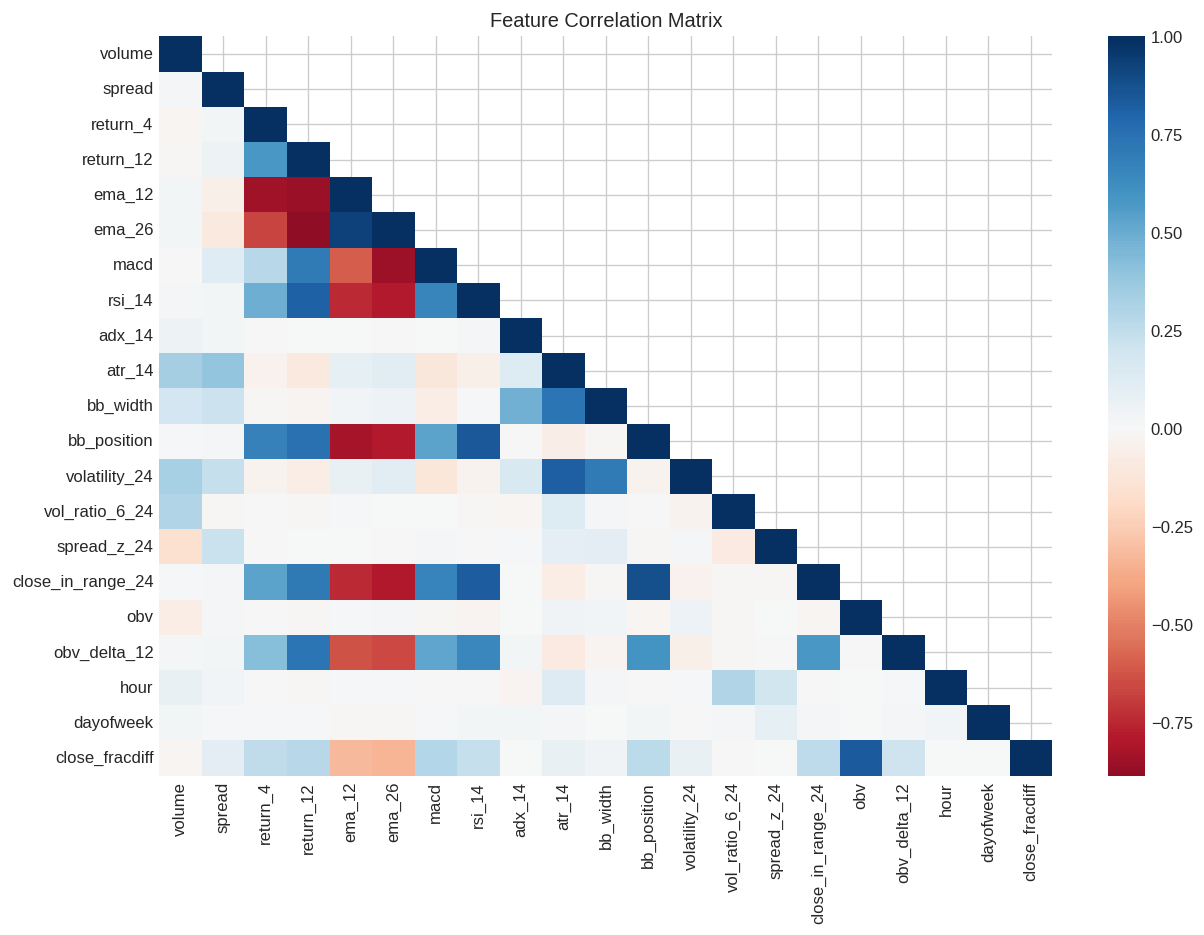

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
_figures.append(fig)

corr_cols = [c for c in features if c in dataset_pdf.columns]
corr = dataset_pdf[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu", center=0,
            xticklabels=corr.columns, yticklabels=corr.columns, ax=ax)
ax.set_title("Feature Correlation Matrix")


## 5d. Feature Distributions by Label Class


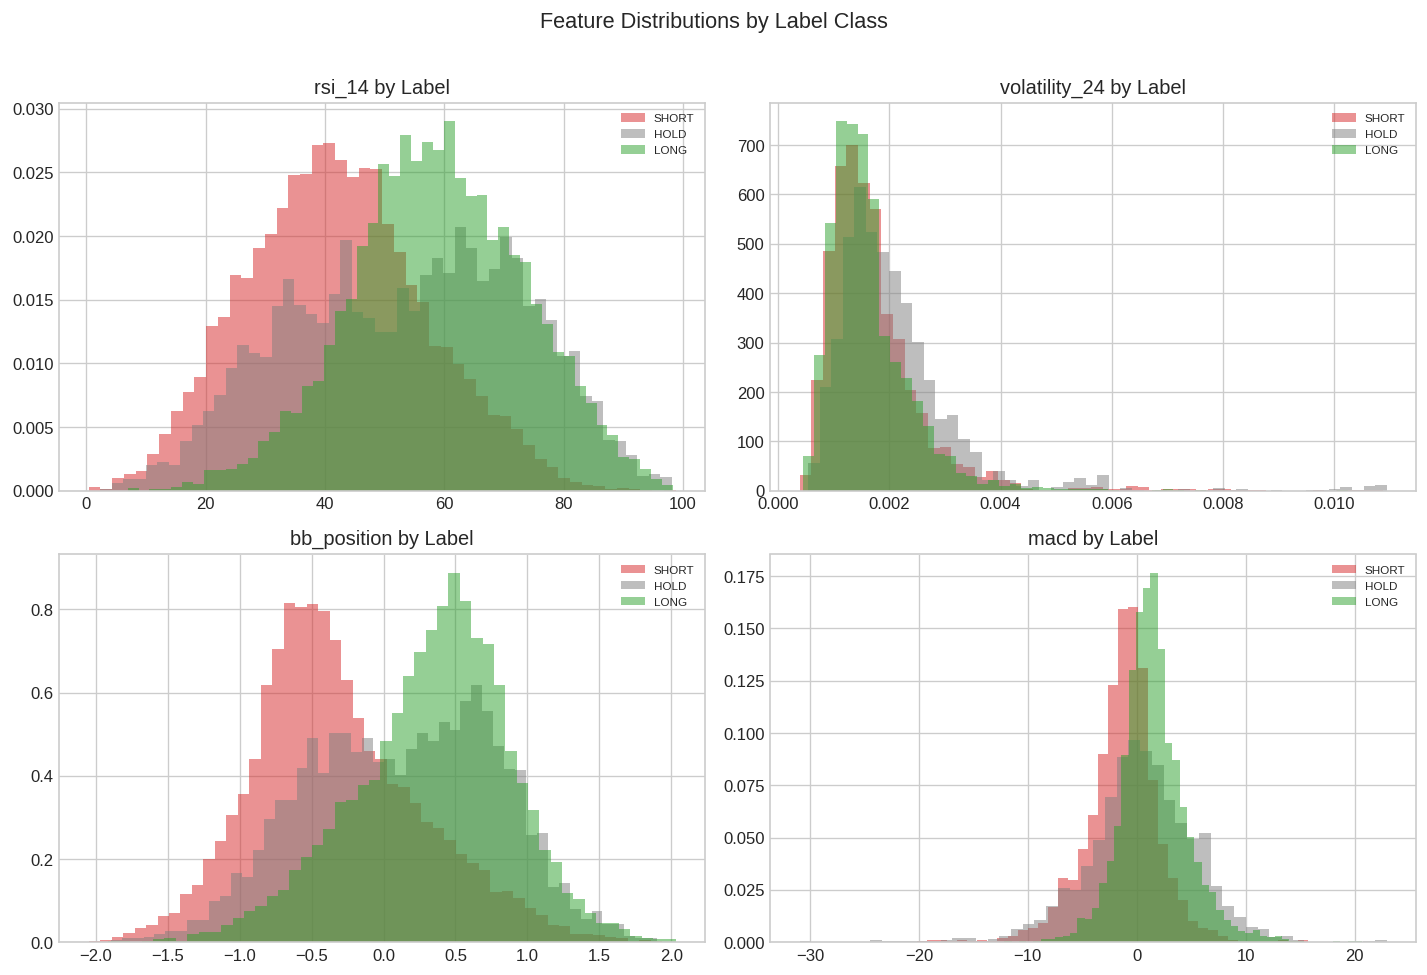

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
_figures.append(fig)

for ax, col in zip(axes.flat, ["rsi_14", "volatility_24", "bb_position", "macd"]):
    for label_val in [-1, 0, 1]:
        subset = dataset_pdf.loc[dataset_pdf["label"] == label_val, col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=PALETTE[label_val], label=LABEL_NAMES[label_val], density=True)
    ax.set_title(f"{col} by Label")
    ax.legend(fontsize=7)

fig.suptitle("Feature Distributions by Label Class", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## 6. Purged Embargo CV Splits


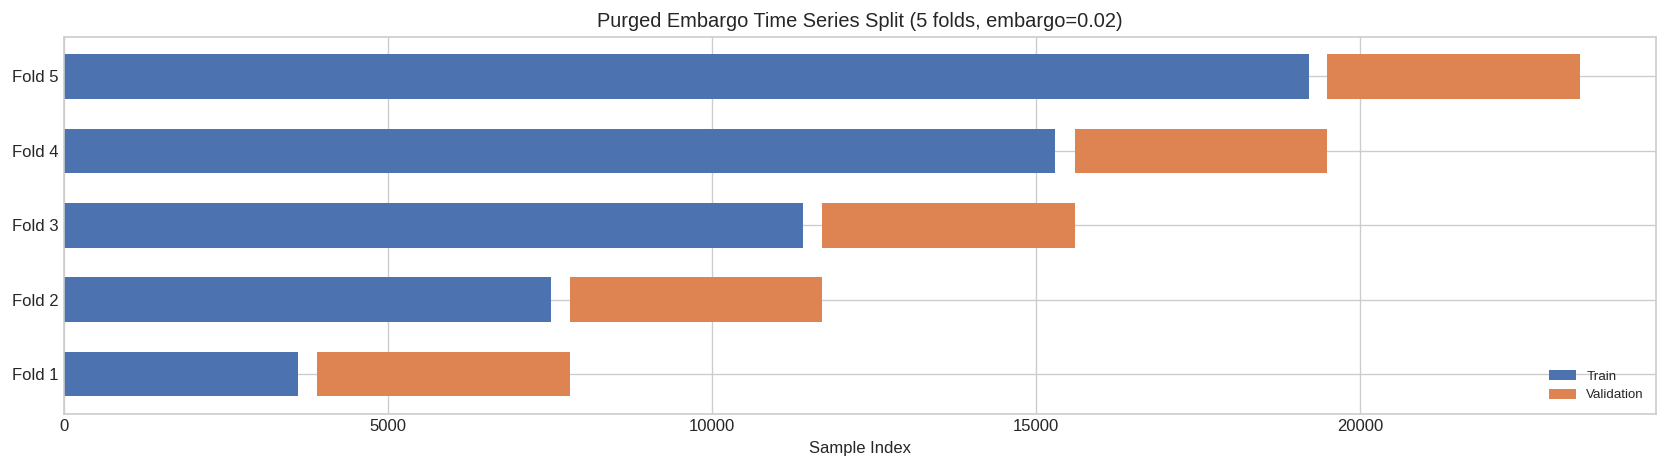

In [9]:
cv = PurgedEmbargoTimeSeriesSplit(CV_SPLITS, EMBARGO_PCT)

fig, ax = plt.subplots(figsize=(14, 4))
_figures.append(fig)

for fold, (train_idx, val_idx) in enumerate(cv.split(train[features], train["event_end"])):
    ax.barh(fold, len(train_idx), left=train_idx[0], color="#4c72b0", height=0.6, label="Train" if fold == 0 else "")
    ax.barh(fold, len(val_idx), left=val_idx[0], color="#dd8452", height=0.6, label="Validation" if fold == 0 else "")

ax.set_yticks(range(CV_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(CV_SPLITS)])
ax.set_xlabel("Sample Index")
ax.set_title(f"Purged Embargo Time Series Split ({CV_SPLITS} folds, embargo={EMBARGO_PCT})")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()


## 7. Model Training


In [10]:
_t_section = time.perf_counter()
model = HybridStackingSignalClassifier(
    n_splits=CV_SPLITS, embargo_pct=EMBARGO_PCT,
    min_oof_f1=MIN_OOF_F1, confidence_threshold=CONFIDENCE_THRESHOLD,
    use_meta_labeling=USE_META_LABELING,
    meta_label_threshold=META_LABEL_THRESHOLD,
    short_meta_label_threshold=SHORT_META_LABEL_THRESHOLD,
    adx_threshold=ADX_THRESHOLD, bb_width_min_mult=BB_WIDTH_MIN_MULT,
    random_state=RANDOM_STATE,
)
model.fit(train[features], train["label"], train["event_end"])
print("Training complete.")
_timings["model_training"] = time.perf_counter() - _t_section


Training complete.


## 8a. OOF Scores & Active Models


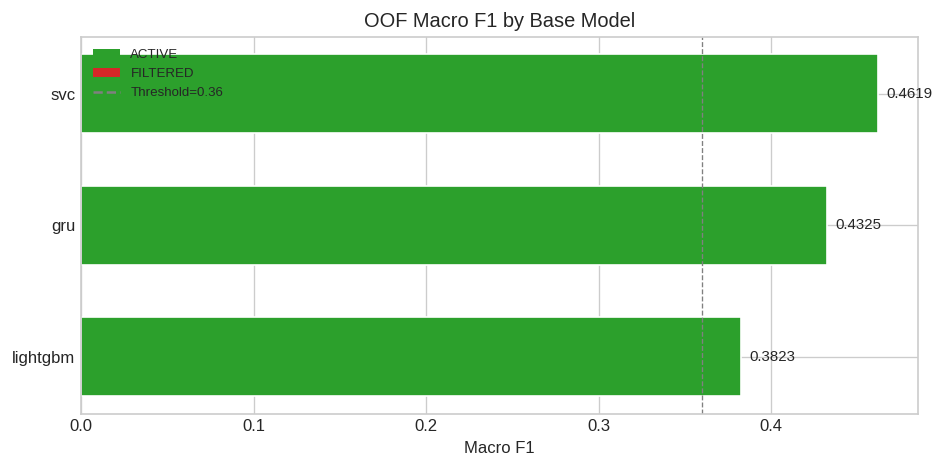

In [11]:
from matplotlib.patches import Patch

scores = pd.Series(model.oof_scores_).sort_values()
colors = ["#2ca02c" if n in model.active_model_names_ else "#d62728" for n in scores.index]

fig, ax = plt.subplots(figsize=(8, 4))
_figures.append(fig)
bars = ax.barh(scores.index, scores.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(MIN_OOF_F1, color="gray", linestyle="--", linewidth=0.8, label=f"Min OOF F1 = {MIN_OOF_F1}")

for bar, val in zip(bars, scores.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)

legend_elements = [
    Patch(facecolor="#2ca02c", label="ACTIVE"),
    Patch(facecolor="#d62728", label="FILTERED"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"Threshold={MIN_OOF_F1}"),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_title("OOF Macro F1 by Base Model")
ax.set_xlabel("Macro F1")
fig.tight_layout()
plt.show()


### 8a. Model Status Table


In [12]:
active_df = pd.DataFrame({
    "Model": list(model.oof_scores_.keys()),
    "OOF F1": [f"{v:.4f}" for v in model.oof_scores_.values()],
    "Status": ["ACTIVE" if n in model.active_model_names_ else "FILTERED" for n in model.oof_scores_],
}).sort_values("OOF F1", ascending=False)

print(f"Active: {len(model.active_model_names_)} / {len(model.oof_scores_)}\n")
print(active_df.to_string(index=False))


Active: 3 / 3

   Model OOF F1 Status
     svc 0.4619 ACTIVE
     gru 0.4325 ACTIVE
lightgbm 0.3823 ACTIVE


## 8b. Test Set Evaluation


In [13]:
predictions = model.predict(test[features])
positions = model.predict_positions(test[features])
pred_proba = model.predict_proba(test[features])

y_true = test["label"].to_numpy()
print(f"Accuracy: {accuracy_score(y_true, predictions):.4f}")
print(f"F1 macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}")
print(classification_report(y_true, predictions, zero_division=0))


Accuracy: 0.6216
F1 macro: 0.5516
              precision    recall  f1-score   support

        -1.0       0.71      0.71      0.71      2329
         0.0       0.32      0.30      0.31       780
         1.0       0.62      0.65      0.63      2155

    accuracy                           0.62      5264
   macro avg       0.55      0.55      0.55      5264
weighted avg       0.62      0.62      0.62      5264



## 8c. Confusion Matrix


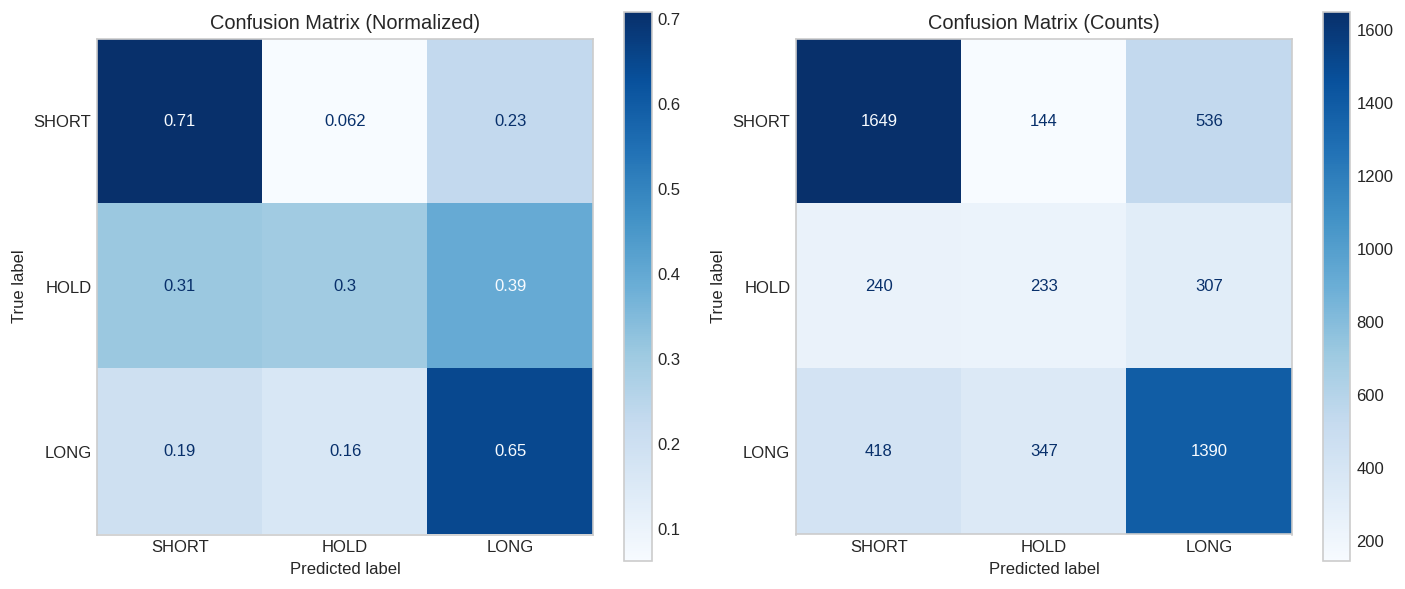

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
_figures.append(fig)

ConfusionMatrixDisplay.from_predictions(
    y_true, predictions, labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=axes[0], normalize="true",
)
axes[0].set_title("Confusion Matrix (Normalized)")

ConfusionMatrixDisplay.from_predictions(
    y_true, predictions, labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=axes[1],
)
axes[1].set_title("Confusion Matrix (Counts)")
for ax in axes:
    ax.grid(False)
fig.tight_layout()
plt.show()


## 8d. Prediction Accuracy Map


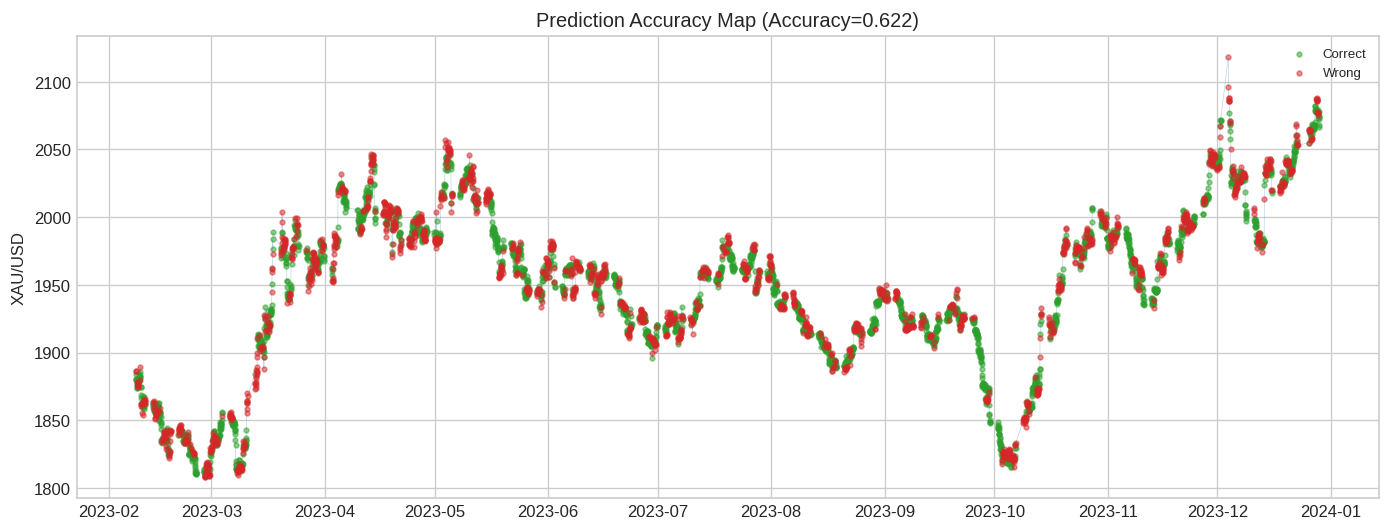

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
_figures.append(fig)

correct = y_true == predictions
ax.scatter(test_pdf.index[correct], test_pdf["close"].iloc[correct], c="#2ca02c", s=8, alpha=0.5, label="Correct", zorder=3)
ax.scatter(test_pdf.index[~correct], test_pdf["close"].iloc[~correct], c="#d62728", s=8, alpha=0.5, label="Wrong", zorder=3)
ax.plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.4, alpha=0.3)

ax.set_title(f"Prediction Accuracy Map (Accuracy={accuracy_score(y_true, predictions):.3f})")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)


## 8e. Predicted Class Probabilities


Text(0.5, 1.02, 'Predicted Class Probabilities Over Test Period')

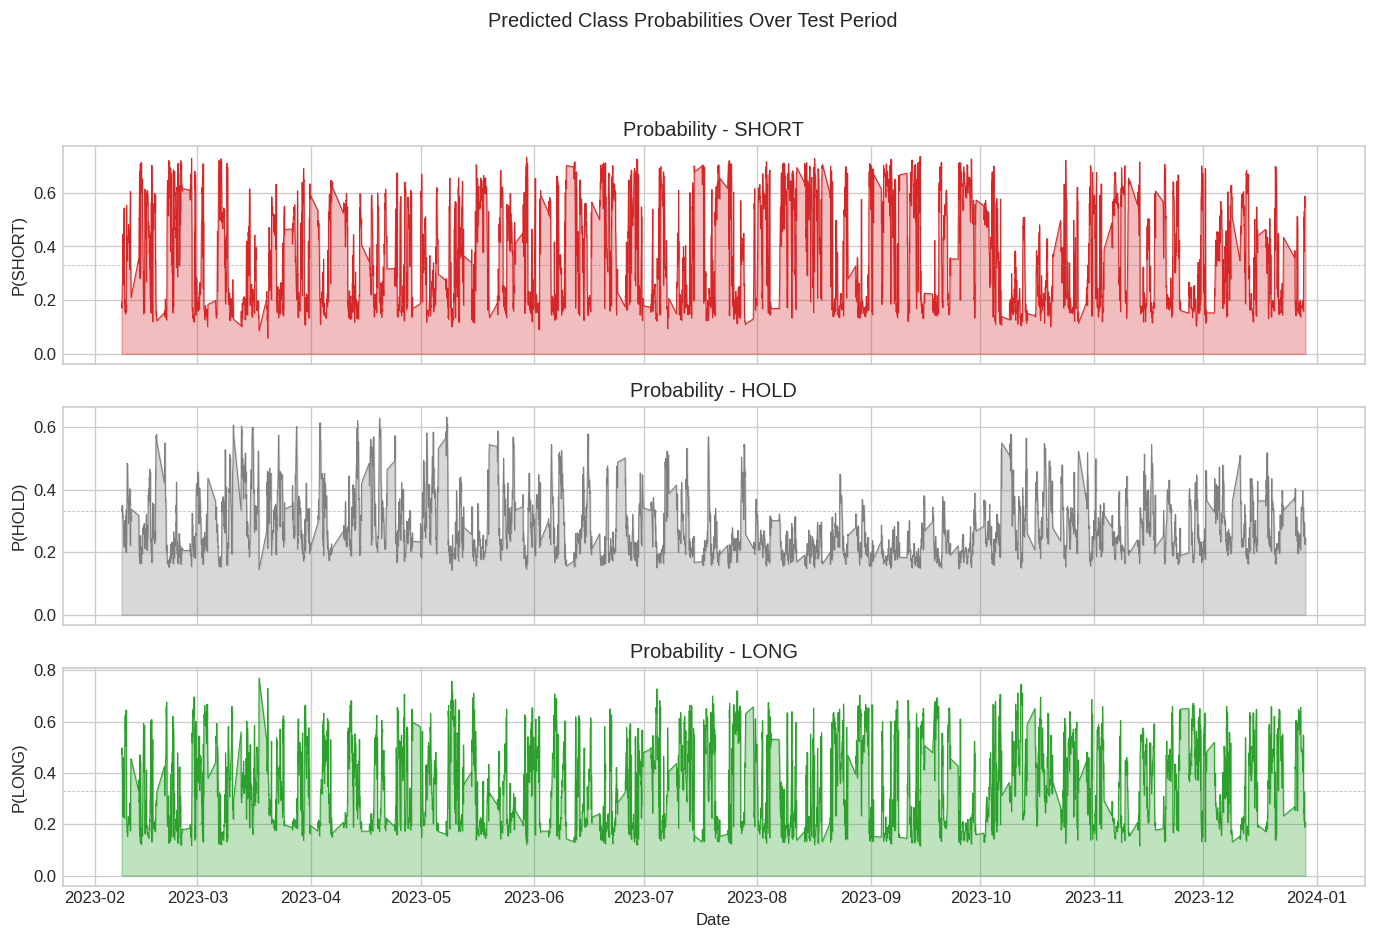

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
_figures.append(fig)

proba_labels = model.label_encoder.inverse_transform(model.meta_model.classes_)
proba_by_label = {label: pred_proba[:, i] for i, label in enumerate(proba_labels)}

for label_val, ax in zip(LABELS, axes):
    values = proba_by_label.get(label_val, np.zeros(len(test_pdf)))
    ax.plot(test_pdf.index, values, color=PALETTE[label_val], linewidth=0.6)
    ax.fill_between(test_pdf.index, 0, values, alpha=0.3, color=PALETTE[label_val])
    ax.axhline(0.33, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_ylabel(f"P({LABEL_NAMES[label_val]})")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"Probability - {LABEL_NAMES[label_val]}")

axes[-1].set_xlabel("Date")
fig.suptitle("Predicted Class Probabilities Over Test Period", fontsize=12, y=1.02)


## 8f. Feature Importance



=== FEATURE IMPORTANCE (LightGBM) ===
   1. obv                         1267   12.8%  #########################
   2. bb_width                     903    9.1%  ##################
   3. volatility_24                812    8.2%  ################
   4. adx_14                       725    7.3%  ##############
   5. macd                         685    6.9%  #############
   6. close_in_range_24            574    5.8%  ###########
   7. close_fracdiff               547    5.5%  ###########
   8. spread                       473    4.8%  #########
   9. atr_14                       440    4.5%  ########
  10. vol_ratio_6_24               440    4.5%  ########


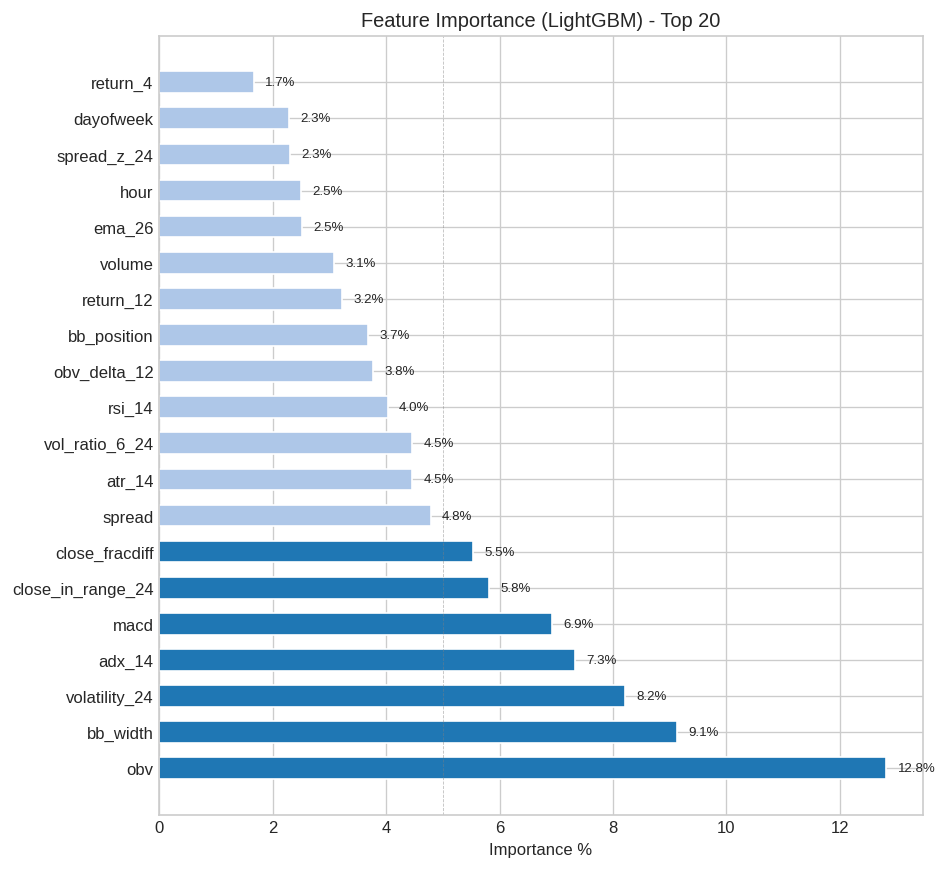

In [17]:
from src.reporting import extract_lightgbm_feature_importance, print_feature_importance_report

imp_df = extract_lightgbm_feature_importance(model, features)
print_feature_importance_report(imp_df)

fig, ax = plt.subplots(figsize=(8, max(6, len(imp_df) * 0.35)))
_figures.append(fig)
top = imp_df.head(20)
colors = ["#1f77b4" if p >= 5.0 else "#aec7e8" for p in top["pct"]]
ax.barh(top["feature"][::-1], top["pct"][::-1], color=colors[::-1], edgecolor="white", height=0.6)
for i, (_, row) in enumerate(top[::-1].iterrows()):
    ax.text(row["pct"] + 0.2, i, f"{row['pct']:.1f}%", va="center", fontsize=8)
ax.axvline(5.0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.invert_yaxis()
ax.set_title("Feature Importance (LightGBM) - Top 20")
ax.set_xlabel("Importance %")
fig.tight_layout()
plt.show()


## 9. Model Architecture


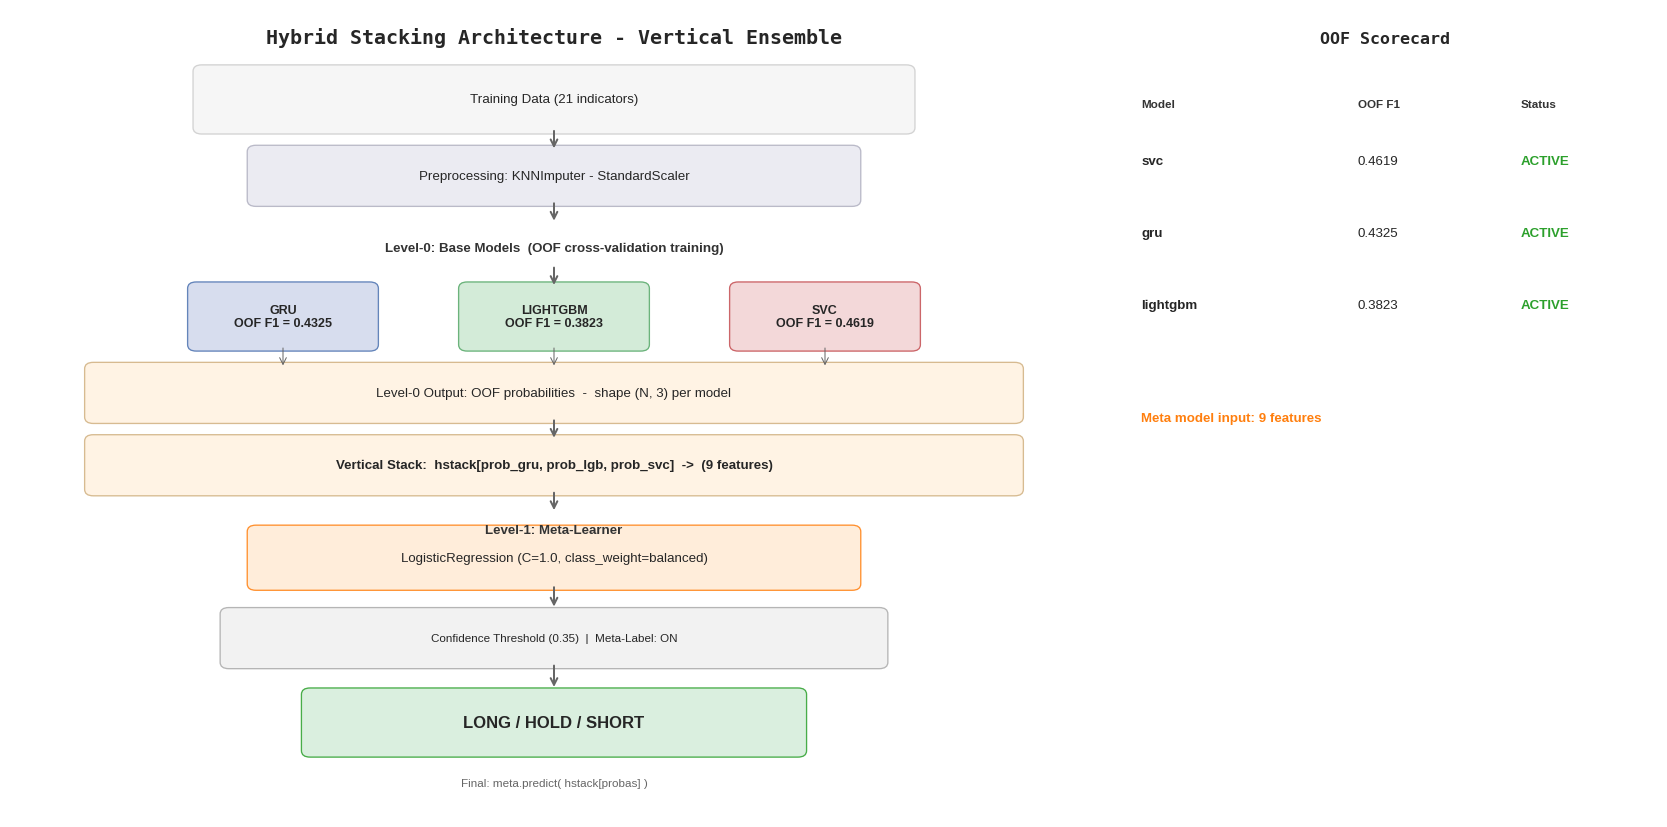

In [18]:
from matplotlib.patches import FancyBboxPatch

n_active = len(model.active_model_names_)
N_FEATURES = len(features)
N_CLASSES = 3
N_META_FEAT = n_active * N_CLASSES

fig, (ax_flow, ax_detail) = plt.subplots(1, 2, figsize=(14, 7),
    gridspec_kw={"width_ratios": [2, 1]})
_figures.append(fig)

ax = ax_flow
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

def _box(ax, x, y, w, h, text, **kw):
    fc = kw.pop("fc", "#e8e8e8")
    ec = kw.pop("ec", "#aaaaaa")
    fs = kw.pop("fs", 8)
    fw = kw.pop("fw", "normal")
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08", fc=fc, ec=ec, lw=0.8, alpha=0.85, zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, fontweight=fw, zorder=3)

def _arrow(ax, y1, y2, x=5, **kw):
    ax.annotate("", xy=(x, y2), xytext=(x, y1),
        arrowprops=dict(arrowstyle="->", color="#666", lw=kw.pop("lw", 1.2)), zorder=4)

def _label(ax, x, y, text, **kw):
    ax.text(x, y, text, ha="center", va="center", fontsize=kw.pop("fs", 7),
            color=kw.pop("color", "#888"), style=kw.pop("style", "normal"),
            fontweight=kw.pop("fw", "normal"))

ax.text(5, 9.6, "Hybrid Stacking Architecture - Vertical Ensemble", ha="center",
        fontsize=12, fontweight="bold", family="monospace")

_box(ax, 5, 8.9, 6.5, 0.7, f"Training Data ({N_FEATURES} indicators)", fc="#f5f5f5", ec="#ccc")
_arrow(ax, 8.55, 8.25)

_box(ax, 5, 7.95, 5.5, 0.6, "Preprocessing: KNNImputer - StandardScaler", fc="#e8e8f0", ec="#b0b0c0")
_arrow(ax, 7.65, 7.35)

_label(ax, 5, 7.05, "Level-0: Base Models  (OOF cross-validation training)", fs=8, fw="bold", color="#333")
_arrow(ax, 6.85, 6.55)

MODEL_COLORS = {"gru": ("#4c72b0", "#d0d8eb"), "lightgbm": ("#55a868", "#cce8d2"), "svc": ("#c44e52", "#f2d2d3")}
base_cx = np.linspace(2.5, 7.5, max(n_active, 1))
for i, name in enumerate(model.active_model_names_):
    ec, fc = MODEL_COLORS.get(name, ("#555", "#eee"))
    oof_f1 = model.oof_scores_.get(name, 0)
    _box(ax, base_cx[i], 6.2, 1.6, 0.7, f"{name.upper()}\nOOF F1 = {oof_f1:.4f}", fc=fc, ec=ec, fs=7.5, fw="bold")
    _arrow(ax, 5.85, 5.55, x=base_cx[i], lw=0.6)

_box(ax, 5, 5.25, 8.5, 0.6,
     f"Level-0 Output: OOF probabilities  -  shape (N, {N_CLASSES}) per model",
     fc="#fff2e0", ec="#d0b080")
_arrow(ax, 4.95, 4.65)

_box(ax, 5, 4.35, 8.5, 0.6,
     f"Vertical Stack:  hstack[prob_gru, prob_lgb, prob_svc]  ->  ({N_META_FEAT} features)",
     fc="#fff2e0", ec="#d0b080", fw="bold")
_arrow(ax, 4.05, 3.75)

_label(ax, 5, 3.55, "Level-1: Meta-Learner", fs=8, fw="bold", color="#333")
_box(ax, 5, 3.2, 5.5, 0.65,
     "LogisticRegression (C=1.0, class_weight=balanced)",
     fc="#ffead4", ec="#ff7f0e")
_arrow(ax, 2.875, 2.55)

_box(ax, 5, 2.2, 6.0, 0.6,
     f"Confidence Threshold ({model.confidence_threshold:.2f})  |  Meta-Label: {'ON' if model.use_meta_labeling else 'OFF'}",
     fc="#f0f0f0", ec="#aaa", fs=7)
_arrow(ax, 1.9, 1.55)

_box(ax, 5, 1.15, 4.5, 0.7, "LONG / HOLD / SHORT",
     fc="#d4edda", ec="#2ca02c", fs=10, fw="bold")
_label(ax, 5, 0.4, "Final: meta.predict( hstack[probas] )", fs=7, color="#666")

ax2 = ax_detail
ax2.axis("off")
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

ax2.text(5, 9.6, "OOF Scorecard", ha="center", fontsize=10, fontweight="bold", family="monospace")
col_headers_y = 8.8
ax2.text(0.5, col_headers_y, "Model", fontsize=7, fontweight="bold", color="#333")
ax2.text(4.5, col_headers_y, "OOF F1", fontsize=7, fontweight="bold", color="#333")
ax2.text(7.5, col_headers_y, "Status", fontsize=7, fontweight="bold", color="#333")

sorted_models = sorted(model.oof_scores_.items(), key=lambda kv: kv[1], reverse=True)
for i, (name, score) in enumerate(sorted_models):
    y = 8.1 - i * 0.9
    status = "ACTIVE" if name in model.active_model_names_ else "FILTERED"
    sc = "#2ca02c" if status == "ACTIVE" else "#d62728"
    ax2.text(0.5, y, name, fontsize=8, fontweight="bold")
    ax2.text(4.5, y, f"{score:.4f}", fontsize=8)
    ax2.text(7.5, y, status, fontsize=8, color=sc, fontweight="bold")

total_y = 8.1 - n_active * 0.9 - 0.5
ax2.text(0.5, total_y, f"Meta model input: {N_META_FEAT} features", fontsize=8,
         color="#ff7f0e", fontweight="bold")
fig.tight_layout()
plt.show()


## 10. Backtest


In [19]:
_t_section = time.perf_counter()

equity_arr, num_trades, executed_trades = simulate_equity_barrier(
    test_pdf["close"].to_numpy(),
    test_pdf["high"].to_numpy(),
    test_pdf["low"].to_numpy(),
    positions,
    spread=test["spread"].to_numpy(),
    atr_rel=test_pdf["atr_14"].to_numpy(),
    initial_balance=INITIAL_BALANCE,
)
trade_signals = int(np.sum(np.diff(positions) != 0))
metrics = aggregate_backtest_metrics(equity_arr, INITIAL_BALANCE, num_trades, trade_signals)

equity = pd.Series(equity_arr, index=test_pdf.index, name="equity")
pnl_usd = np.diff(equity_arr, prepend=equity_arr[0])
account_returns = np.diff(equity_arr) / equity_arr[:-1]
account_returns = np.nan_to_num(account_returns, nan=0.0, posinf=0.0, neginf=0.0)
account_returns = np.concatenate([[0.0], account_returns])

bh_equity = (INITIAL_BALANCE * test_pdf["close"] / test_pdf["close"].iloc[0]).rename("bh_equity")
_timings["backtesting"] = time.perf_counter() - _t_section


### 10a. Equity Curve, Drawdown, Positions


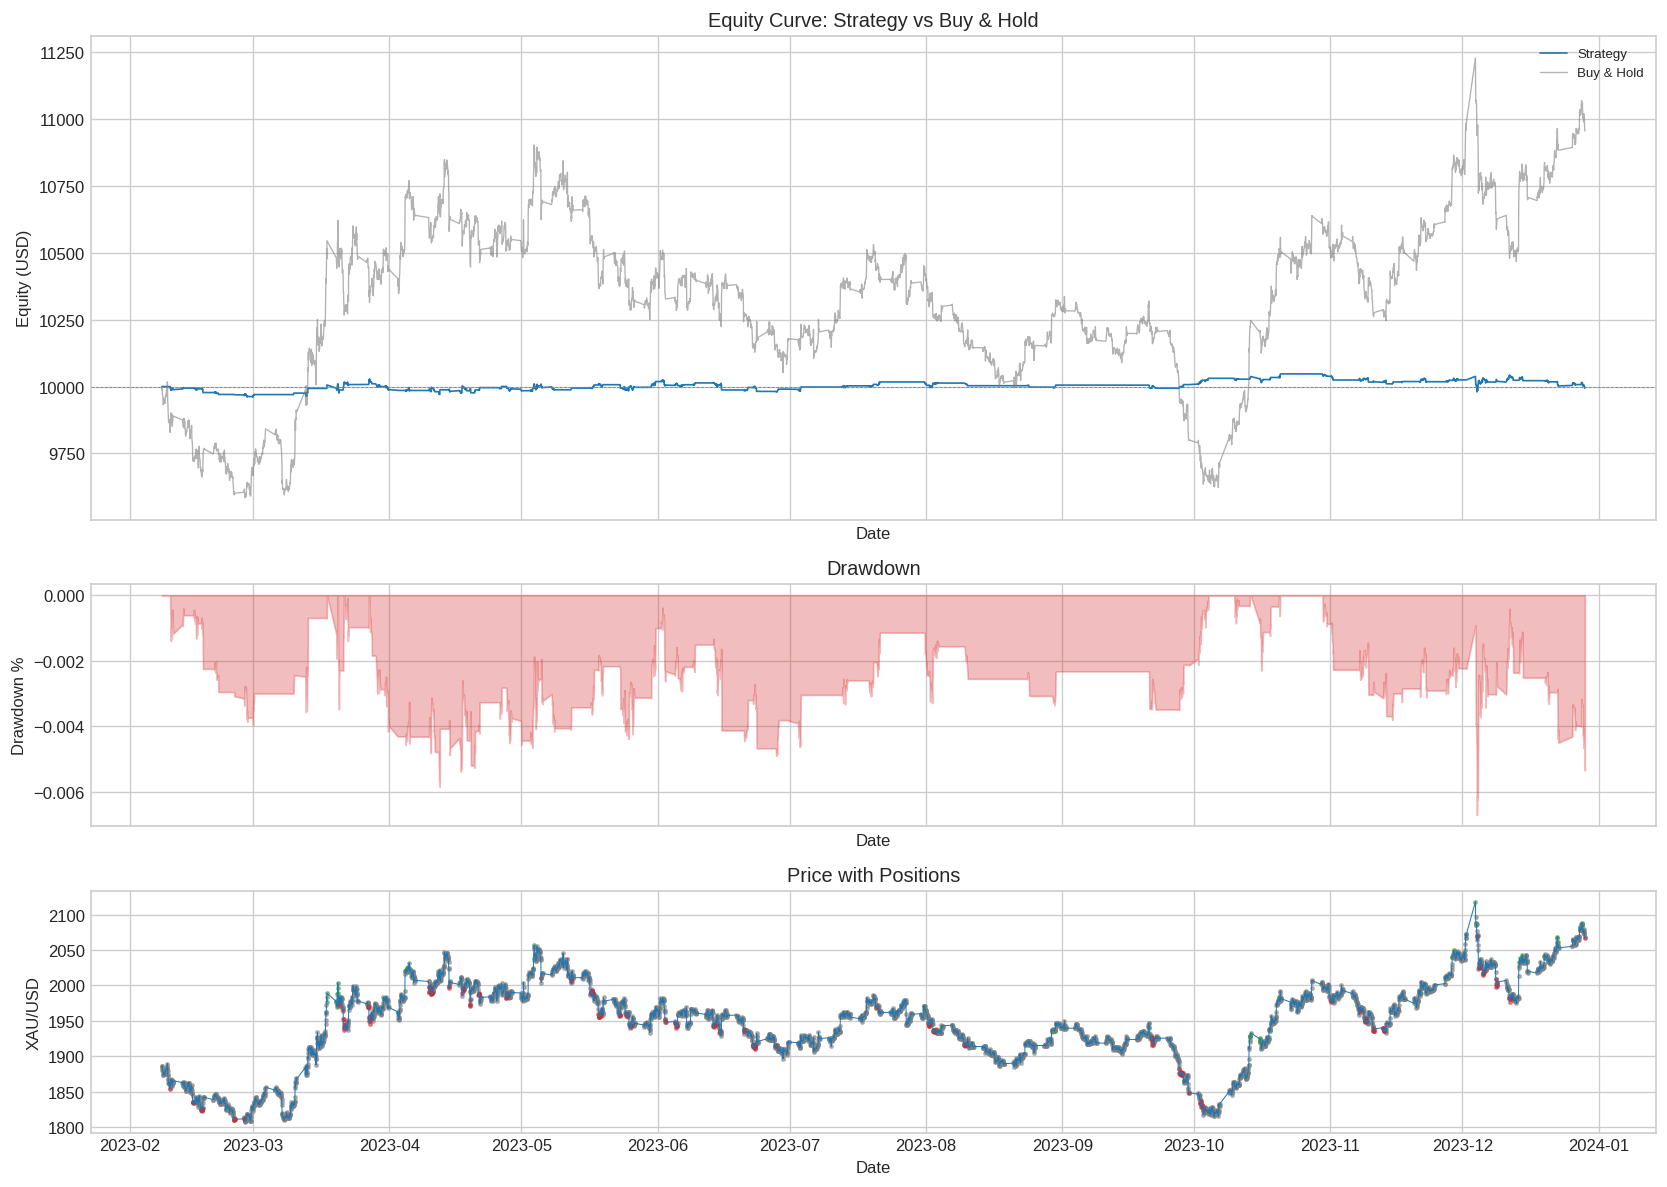

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, height_ratios=[2, 1, 1])
_figures.append(fig)

axes[0].plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
axes[0].plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
axes[0].axhline(INITIAL_BALANCE, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_title("Equity Curve: Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity (USD)")
axes[0].legend(fontsize=8)

drawdown = (equity - equity.cummax()) / equity.cummax()
axes[1].fill_between(equity.index, drawdown.values, 0, alpha=0.3, color="#d62728")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown %")

axes[2].plot(test_pdf.index, test_pdf["close"], color="#1f77b4", linewidth=0.6)
positions_series = pd.Series(positions, index=test_pdf.index)
for label_val, color in PALETTE.items():
    mask = positions_series == label_val
    axes[2].scatter(test_pdf.index[mask], test_pdf.loc[mask, "close"], c=color, s=4, alpha=0.5)
axes[2].set_title("Price with Positions")
axes[2].set_ylabel("XAU/USD")

for ax in axes:
    ax.set_xlabel("Date")
fig.tight_layout()


### 10b. PnL Analysis


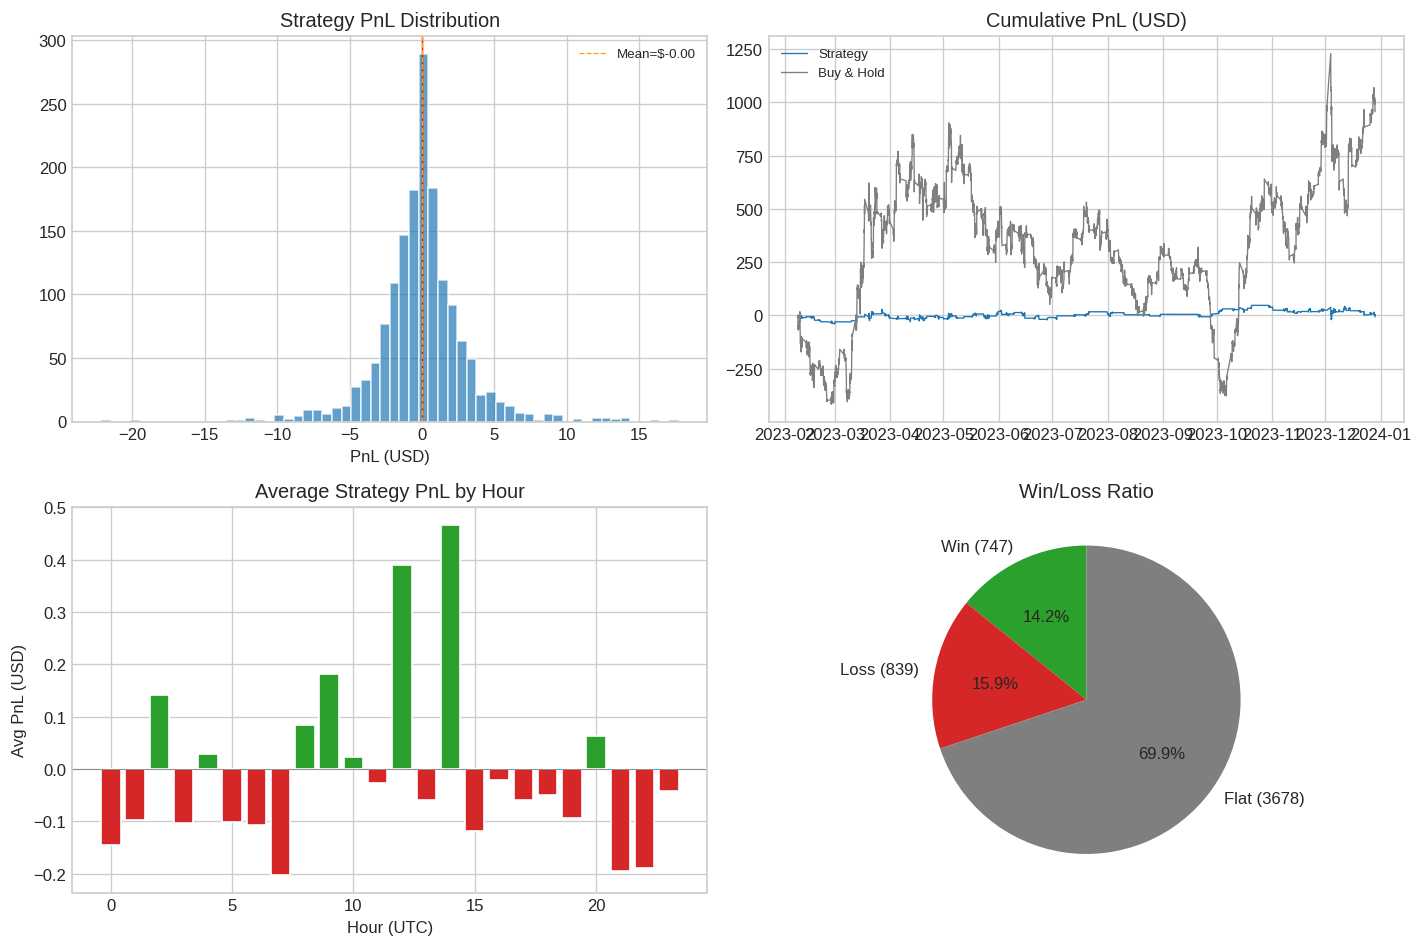

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
_figures.append(fig)

nonzero_pnl = pnl_usd[pnl_usd != 0]
mean_pnl = np.mean(nonzero_pnl) if len(nonzero_pnl) else 0.0
axes[0, 0].hist(nonzero_pnl, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="red", linewidth=0.8)
axes[0, 0].axvline(mean_pnl, color="orange", linewidth=0.8, linestyle="--", label=f"Mean=${mean_pnl:.2f}")
axes[0, 0].set_title("Strategy PnL Distribution")
axes[0, 0].set_xlabel("PnL (USD)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(test_pdf.index, equity - INITIAL_BALANCE, color="#1f77b4", linewidth=0.8, label="Strategy")
axes[0, 1].plot(test_pdf.index, bh_equity - INITIAL_BALANCE, color="#7f7f7f", linewidth=0.8, label="Buy & Hold")
axes[0, 1].set_title("Cumulative PnL (USD)")
axes[0, 1].legend(fontsize=8)

hourly = pd.DataFrame({"hour": test_pdf.index.hour, "pnl_usd": pnl_usd})
hourly_grouped = hourly.groupby("hour")["pnl_usd"].mean()
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in hourly_grouped.values]
axes[1, 0].bar(hourly_grouped.index, hourly_grouped.values, color=bar_colors, edgecolor="white")
axes[1, 0].axhline(0, color="gray", linewidth=0.5)
axes[1, 0].set_title("Average Strategy PnL by Hour")
axes[1, 0].set_xlabel("Hour (UTC)")
axes[1, 0].set_ylabel("Avg PnL (USD)")

wins = (pnl_usd > 0).sum()
losses = (pnl_usd < 0).sum()
neutral = (pnl_usd == 0).sum()
axes[1, 1].pie(
    [wins, losses, neutral],
    labels=[f"Win ({wins})", f"Loss ({losses})", f"Flat ({neutral})"],
    colors=["#2ca02c", "#d62728", "#7f7f7f"],
    autopct="%.1f%%", startangle=90)
axes[1, 1].set_title("Win/Loss Ratio")

fig.tight_layout()
plt.show()


## 11. Rolling Performance


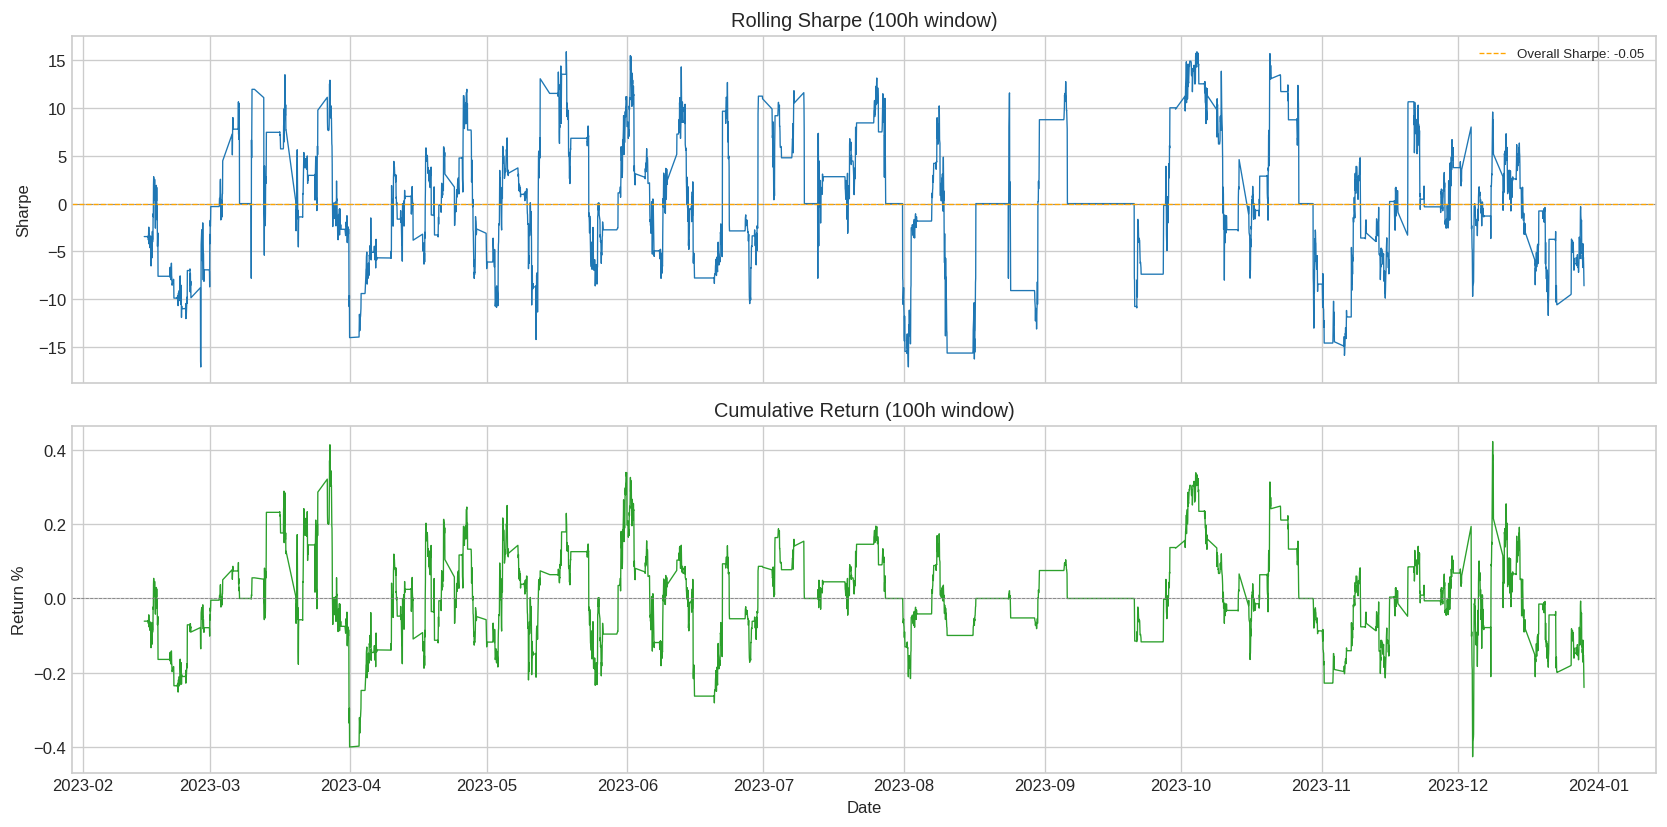

In [22]:
window = max(1, min(100, len(account_returns) // 3))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
_figures.append(fig)

rolling_sharpe = pd.Series(account_returns).rolling(window).apply(
    lambda x: np.sqrt(24 * 252) * x.mean() / x.std() if x.std() > 0 else 0, raw=True)
axes[0].plot(test_pdf.index, rolling_sharpe.values, color="#1f77b4", linewidth=0.8)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].axhline(metrics["sharpe"], color="orange", linewidth=0.8, linestyle="--", label=f"Overall Sharpe: {metrics['sharpe']:.2f}")
axes[0].set_title(f"Rolling Sharpe ({window}h window)")
axes[0].set_ylabel("Sharpe")
axes[0].legend(fontsize=8)

rolling_ret = pd.Series(account_returns).rolling(window).sum() * 100
axes[1].plot(test_pdf.index, rolling_ret.values, color="#2ca02c", linewidth=0.8)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_title(f"Cumulative Return ({window}h window)")
axes[1].set_ylabel("Return %")
axes[1].set_xlabel("Date")

fig.tight_layout()


## 12. Summary Dashboard


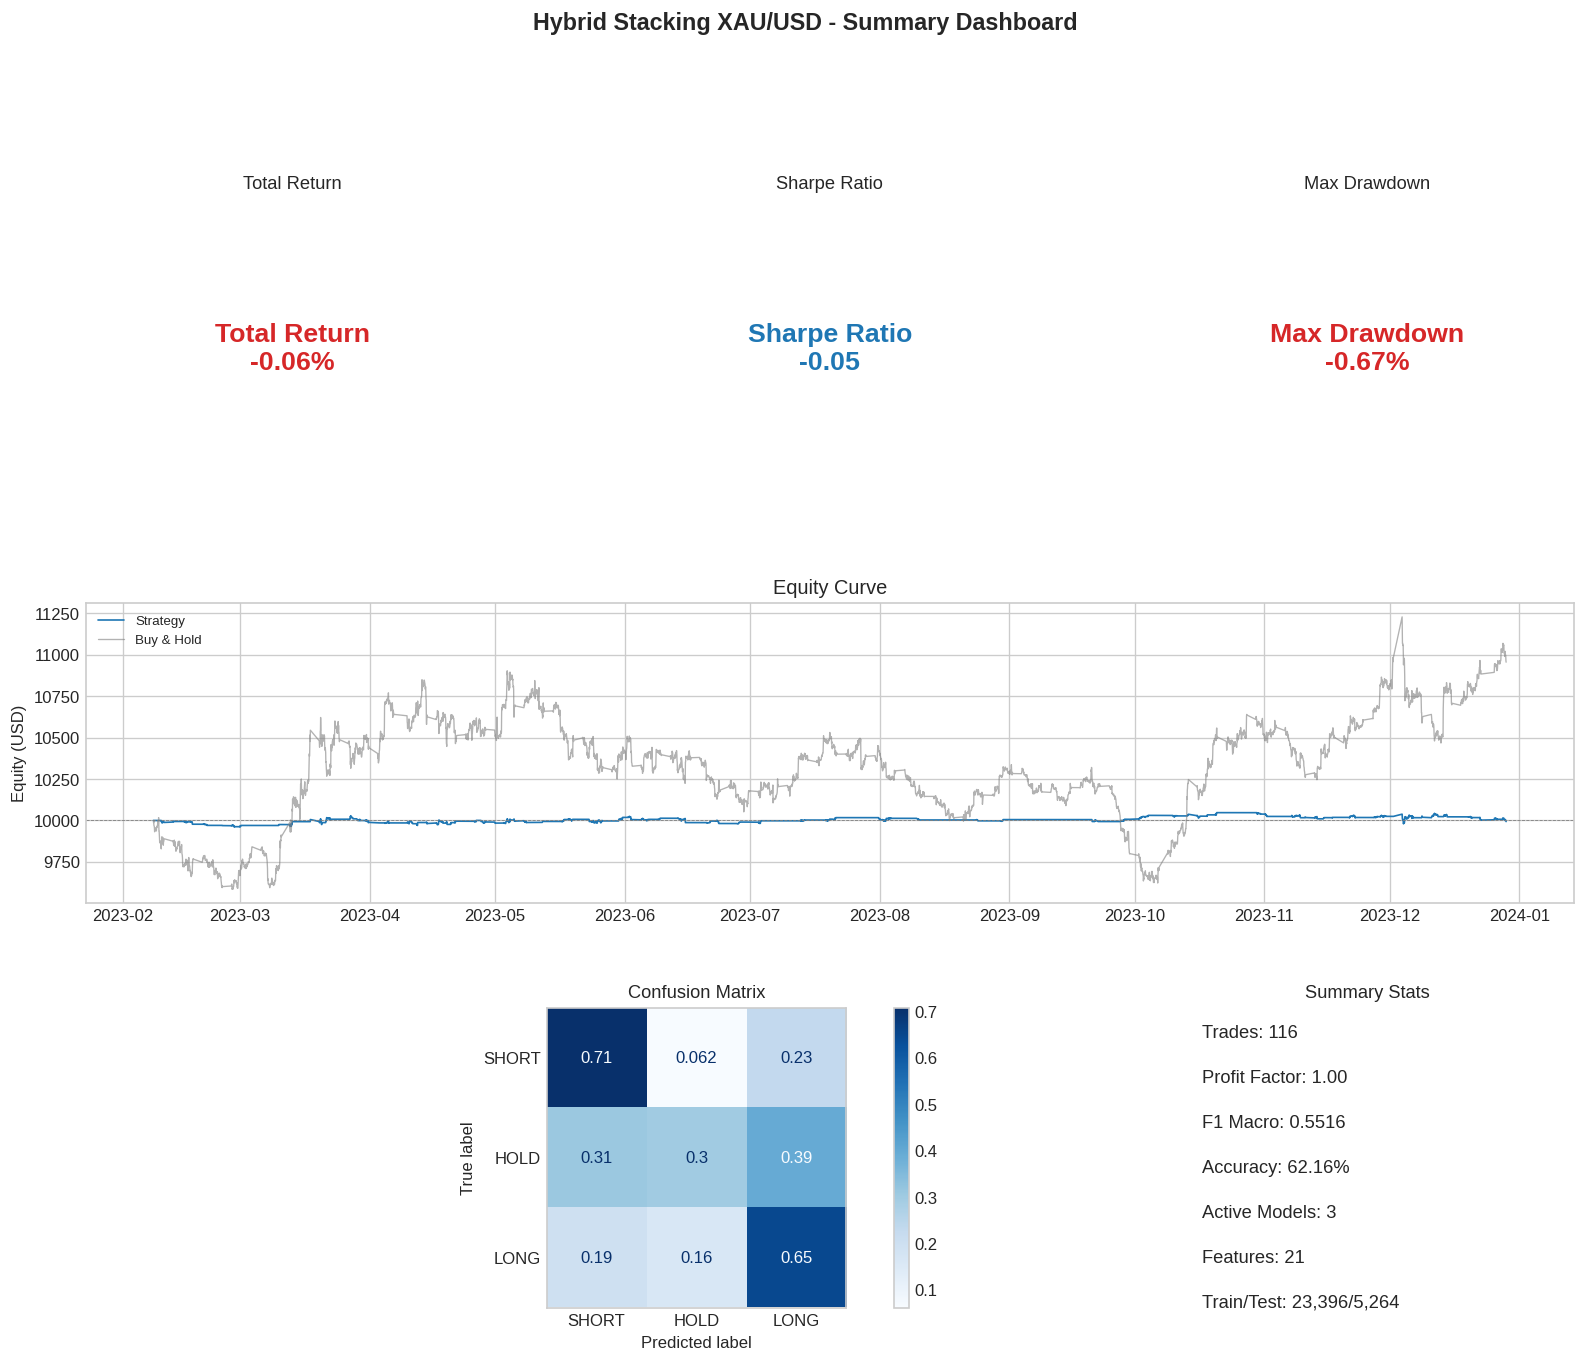

In [23]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
_figures.append(fig)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, f"Total Return\n{metrics['total_return']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#2ca02c" if metrics["total_return"] > 0 else "#d62728",
         transform=ax1.transAxes)
ax1.set_title("Total Return", fontsize=11)
ax1.axis("off")

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.5, f"Sharpe Ratio\n{metrics['sharpe']:.2f}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#1f77b4", transform=ax2.transAxes)
ax2.set_title("Sharpe Ratio", fontsize=11)
ax2.axis("off")

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.5, f"Max Drawdown\n{metrics['max_drawdown']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#d62728", transform=ax3.transAxes)
ax3.set_title("Max Drawdown", fontsize=11)
ax3.axis("off")

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
ax4.plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
ax4.axhline(INITIAL_BALANCE, color="gray", linewidth=0.5, linestyle="--")
ax4.set_title("Equity Curve")
ax4.legend(fontsize=8)
ax4.set_ylabel("Equity (USD)")

ax5 = fig.add_subplot(gs[2, :2])
ConfusionMatrixDisplay.from_predictions(
    y_true, predictions, labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=ax5, normalize="true")
ax5.set_title("Confusion Matrix", fontsize=11)
ax5.grid(False)

ax6 = fig.add_subplot(gs[2, 2])
ax6.text(0.1, 0.9, f"Trades: {int(metrics['trades'])}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.75, f"Profit Factor: {metrics['profit_factor']:.2f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.6, f"F1 Macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.45, f"Accuracy: {accuracy_score(y_true, predictions):.2%}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.3, f"Active Models: {len(model.active_model_names_)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.15, f"Features: {len(features)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.0, f"Train/Test: {len(train):,}/{len(test):,}", transform=ax6.transAxes, fontsize=11)
ax6.set_title("Summary Stats", fontsize=11)
ax6.axis("off")

fig.suptitle("Hybrid Stacking XAU/USD - Summary Dashboard", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 13. Export


In [24]:
_t_section = time.perf_counter()
from datetime import datetime
import json

from src.reporting import (
    persist_run_artifacts,
    save_equity_curve_plot,
    save_oof_scores_bar_plot,
    save_feature_importance_bar_plot,
    save_feature_importance_csv,
)

config_payload = {
    "months": months_label,
    "data_range": file_range,
    "cv_splits": CV_SPLITS,
    "embargo_pct": EMBARGO_PCT,
    "purge_pct": PURGE_PCT,
    "fractional_d": FRACTIONAL_D,
    "auto_tune_barriers": AUTO_TUNE_BARRIERS,
    "fallback_tp_atr": FALLBACK_TP_ATR,
    "fallback_sl_atr": FALLBACK_SL_ATR,
    "max_loss_atr": MAX_LOSS_ATR,
    "labeling_horizon": LABELING_HORIZON,
    "swing_window": SWING_WINDOW,
    "tune_tp_range": TUNE_TP_RANGE,
    "tune_sl_range": TUNE_SL_RANGE,
    "tune_target_balance": TUNE_TARGET_BALANCE,
    "min_oof_f1": MIN_OOF_F1,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "use_meta_labeling": USE_META_LABELING,
    "meta_label_threshold": META_LABEL_THRESHOLD,
    "adx_threshold": ADX_THRESHOLD,
    "random_state": RANDOM_STATE,
    "timeframe": config.timeframe,
    "initial_balance": INITIAL_BALANCE,
}

run_id = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir = REPORT_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

persist_run_artifacts(
    run_dir=run_dir,
    model=model,
    test=test,
    predictions=predictions,
    positions=positions,
    config_payload=config_payload,
    dataset=dataset,
    train=train,
    test_df=test,
    features=features,
    backtest_metrics=metrics,
    executed_trades=executed_trades,
    equity=equity_arr,
)

# Save extra notebook-specific figures
figures_dir = run_dir / "figures"
figures_dir.mkdir(exist_ok=True)
FIGURE_NAMES = [
    "label_distribution",
    "fracdiff_comparison",
    "technical_indicators",
    "feature_correlation",
    "feature_distributions_by_label",
    "cv_splits",
    "oof_scores",
    "confusion_matrix",
    "prediction_accuracy_map",
    "predicted_probabilities",
    "feature_importance",
    "model_architecture",
    "equity_drawdown_positions",
    "pnl_analysis",
    "rolling_performance",
    "summary_dashboard",
]
for fig, name in zip(_figures, FIGURE_NAMES):
    fig.savefig(figures_dir / f"{name}.png", dpi=160, bbox_inches="tight")

# Append notebook-specific fields to run_data.json
run_data_path = run_dir / "run_data.json"
with open(run_data_path) as f:
    run_data = json.load(f)
run_data["reproducibility"]["run_entrypoint"] = "notebook"
_timings["total"] = time.perf_counter() - _t0
run_data["timing"] = {k: round(v, 4) for k, v in _timings.items()}
with open(run_data_path, "w", encoding="utf-8") as f:
    json.dump(run_data, f, indent=2, ensure_ascii=False)

print(f"Run saved to: {run_dir}")
print(f"Files: {len(_figures)} figures, predictions.csv, trades.csv, backtest_metrics.csv, feature_importance.csv, run_data.json")

print("\n=== PIPELINE TIMING ===")
for step, elapsed in sorted(_timings.items(), key=lambda x: x[1], reverse=True):
    print(f"  {step}: {elapsed:.4f}s")
print(f"  TOTAL: {_timings['total']:.4f}s")



Run dir: /home/ultimatebrok/Downloads/thesis-compact/reports/run_20260529_063637
Files: predictions.csv, trades.csv (116 trades), backtest_metrics.csv, feature_importance.csv, run_data.json, figures/*.png
Run saved to: reports/run_20260529_063637
Files: 16 figures, predictions.csv, trades.csv, backtest_metrics.csv, feature_importance.csv, run_data.json

=== PIPELINE TIMING ===
  total: 525.7599s
  model_training: 487.7661s
  data_loading: 10.5461s
  backtesting: 0.0725s
  config: 0.0086s
  TOTAL: 525.7599s
